# Module 3 · Assignment 2 — Unsupervised Learning
### DS23 · Certified Data Scientist with Agentic AI · by Shlomit Levavi

**This is a guided starter notebook, not a solution.** Fill every `# TODO`.
The model is the easy 30%. The interrogation in `REPORT.md` is the graded 70%.

Pick **one** option in Part 1. Write all code and comments in **English**.

**Workflow (6 stations):** 1) Frame  2) Data & scaling  3) Build >=2 approaches
4) Validate the structure  5) Interrogate  6) Translate (Structure Card).

> There is no ground truth here. "Good" is something you must argue for, not measure.


## Part 1 · Setup, data, scaling

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Choose ONE option
| Option | Task | Notes |
|---|---|---|
| A | Olist customer segmentation | ~97% of customers buy once -> drop frequency; use recency, monetary, basket. |
| B | Credit Card behavioral segmentation | 18 features, needs scaling + PCA. Fresh. |
| C | Olist anomaly detection | Isolation Forest / LOF. Anomalies = candidates, not fraud. |

In [6]:
OLIST_DIR = "/content/drive/MyDrive/Colab Notebooks/שעורי בית/"

def load_olist_customers_behavioral(olist_dir=OLIST_DIR):
    # טעינת נתונים בסיסיים
    orders = pd.read_csv(olist_dir + "olist_orders_dataset.csv")
    items  = pd.read_csv(olist_dir + "olist_order_items_dataset.csv")
    prods  = pd.read_csv(olist_dir + "olist_products_dataset.csv")
    cust   = pd.read_csv(olist_dir + "olist_customers_dataset.csv")

    # חיבור מוצרים לקטגוריות
    items = items.merge(prods[["product_id", "product_category_name"]], on="product_id")
    # חיבור לקוחות להזמנות
    o = orders.merge(cust[["customer_id", "customer_unique_id"]], on="customer_id")
    full_df = o.merge(items, on="order_id")

    # יצירת פיצ'רים של העדפות קטגוריות (למשל: כמה פעמים הלקוח קנה בכל קטגוריה)
    behavioral_df = pd.pivot_table(full_df, index="customer_unique_id",
                                   columns="product_category_name",
                                   aggfunc="size", fill_value=0)

    return behavioral_df

df = load_olist_customers_behavioral()

### Scaling
Distance-based methods (KMeans, DBSCAN) are dominated by large-scale features.
Scale before clustering, and be ready to show how scaling changed the result.

In [7]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
features = [col for col in numeric_cols if col not in ['customer_id', 'customer_unique_id']]

X = df[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=features)


print("--- Variance BEFORE scaling ---")
print("Notice how some categories dominate due to high variance:")
print(X.var().sort_values(ascending=False).head())

print("\n--- Variance AFTER scaling ---")
print("All features now have a variance of 1.0, giving them equal weight:")
print(X_scaled_df.var().head())


--- Variance BEFORE scaling ---
Notice how some categories dominate due to high variance:
product_category_name
cama_mesa_banho           0.166366
moveis_decoracao          0.153442
informatica_acessorios    0.126580
beleza_saude              0.125584
esporte_lazer             0.116820
dtype: float64

--- Variance AFTER scaling ---
All features now have a variance of 1.0, giving them equal weight:
agro_industria_e_comercio    1.000011
alimentos                    1.000011
alimentos_bebidas            1.000011
artes                        1.000011
artes_e_artesanato           1.000011
dtype: float64


---
## Part 2 · Build at least two approaches
Clustering: KMeans + one of Hierarchical / DBSCAN. Choose k with **Elbow and
Silhouette**, and note where they disagree. Anomaly (Option C): Isolation Forest + LOF.

Calculating KMeans for k=2 to 10. This might take a minute...


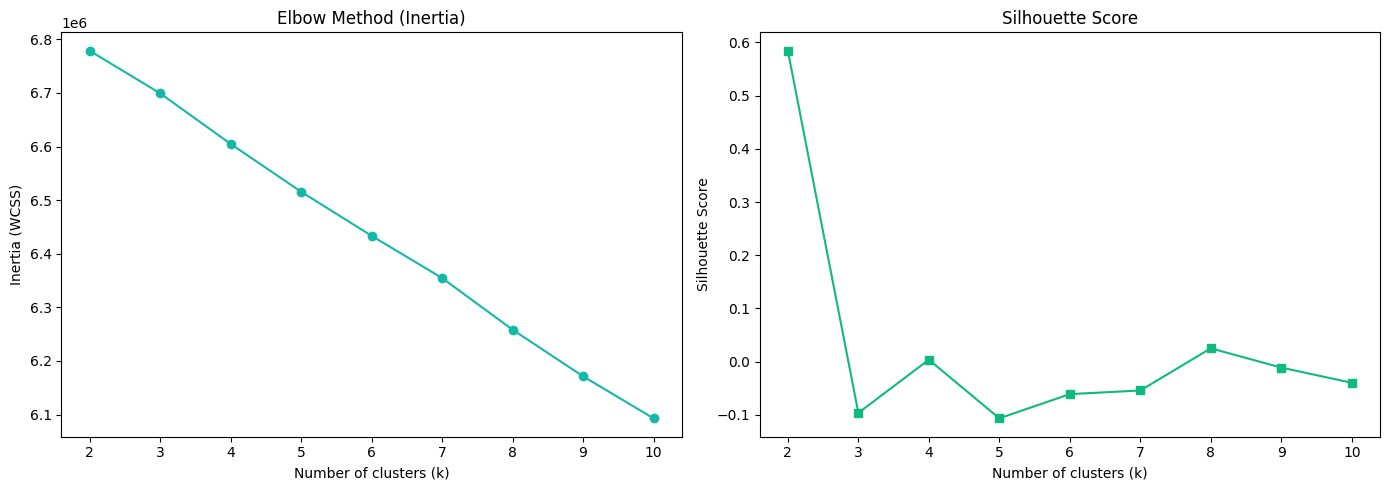

In [10]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
inertias = []
sils = []
K_range = range(2, 11)

sample_size_for_sil = 10000 if len(X_scaled_df) > 10000 else None

print("Calculating KMeans for k=2 to 10. This might take a minute...")

for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled_df)


    inertias.append(km.inertia_)
    sil = silhouette_score(X_scaled_df, labels, sample_size=sample_size_for_sil, random_state=RANDOM_STATE)
    sils.append(sil)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, marker='o', color='#14b8a6')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('Inertia (WCSS)')
ax1.set_xticks(K_range)

ax2.plot(K_range, sils, marker='s', color='#10b981')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_xticks(K_range)

plt.tight_layout()
plt.show()

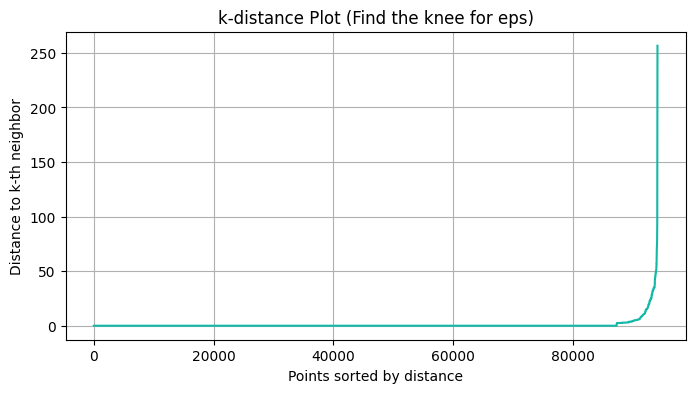


Models fitted successfully! DBSCAN Noise points (-1): 7.2%


In [12]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

best_k = 4

kmeans_model = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
df['cluster_kmeans'] = kmeans_model.fit_predict(X_scaled_df)

kmeans_model = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
df['cluster_kmeans'] = kmeans_model.fit_predict(X_scaled_df)

min_samples_db = 2 * X_scaled_df.shape[1]

nn = NearestNeighbors(n_neighbors=min_samples_db)
nn.fit(X_scaled_df)
distances, indices = nn.kneighbors(X_scaled_df)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances, color='#14b8a6')
plt.title('k-distance Plot (Find the knee for eps)')
plt.ylabel('Distance to k-th neighbor')
plt.xlabel('Points sorted by distance')
plt.grid(True)
plt.show()

eps_value = 1.5

dbscan_model = DBSCAN(eps=eps_value, min_samples=min_samples_db)
df['cluster_dbscan'] = dbscan_model.fit_predict(X_scaled_df)

noise_ratio = (df['cluster_dbscan'] == -1).mean() * 100
print(f"\nModels fitted successfully! DBSCAN Noise points (-1): {noise_ratio:.1f}%")

---
## Part 3 · Validate the structure
Report silhouette, cluster sizes, a PCA 2D view, and **stability** (re-run with new
seeds / on a subsample). For Option C: the score distribution and a percentile threshold.

Running PCA to reduce dimensions to 2D...


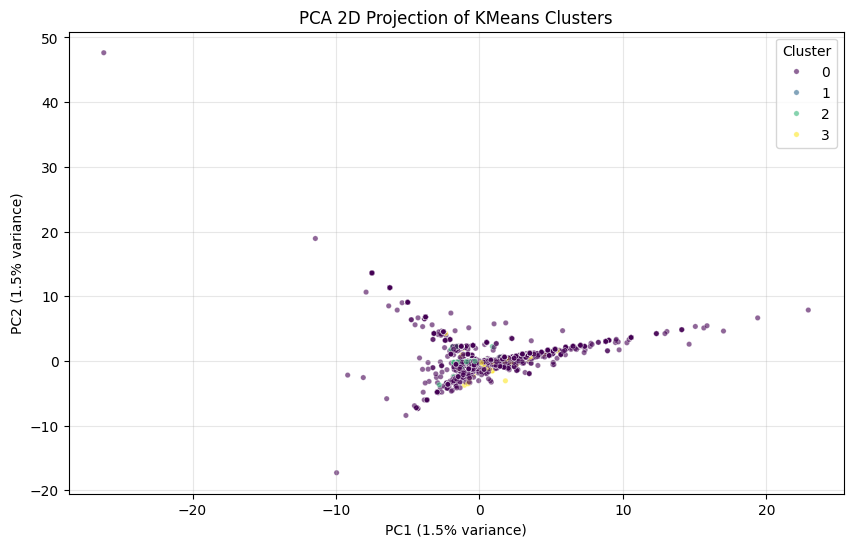


--- Stability Check (Cluster Sizes across different random seeds) ---
Seed  42: C0: 93.6%, C1: 0.0%, C2: 3.3%, C3: 3.0%
Seed 123: C0: 8.0%, C1: 0.0%, C2: 0.7%, C3: 91.3%
Seed 999: C0: 96.6%, C1: 0.1%, C2: 3.3%, C3: 0.0%


In [14]:
import seaborn as sns
print("Running PCA to reduce dimensions to 2D...")

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled_df)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=coords[:,0], y=coords[:,1], hue=df['cluster_kmeans'],
                palette='viridis', alpha=0.6, s=15)

var_ratio = pca.explained_variance_ratio_
plt.title('PCA 2D Projection of KMeans Clusters')
plt.xlabel(f'PC1 ({var_ratio[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({var_ratio[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Stability Check (Cluster Sizes across different random seeds) ---")

seeds_to_test = [42, 123, 999]
best_k = 4

for seed in seeds_to_test:
    test_km = KMeans(n_clusters=best_k, n_init=10, random_state=seed)
    test_labels = test_km.fit_predict(X_scaled_df)


    sizes = pd.Series(test_labels).value_counts(normalize=True).sort_index() * 100

    sizes_str = ", ".join([f"C{i}: {val:.1f}%" for i, val in sizes.items()])
    print(f"Seed {seed:3}: {sizes_str}")

---
## Part 4 · Interrogate
Are clusters real or artifacts of scaling / k / the algorithm's assumptions?
Profile each cluster: which 2-3 features separate them? Is any cluster just noise?

In [15]:
cluster_profiles = df.groupby("cluster_kmeans")[features].mean()

print("--- Cluster Profiles (Means) ---")

print(cluster_profiles.T.round(2))

print("\n--- Cluster Sizes (Absolute count) ---")
print(df["cluster_kmeans"].value_counts())


--- Cluster Profiles (Means) ---
cluster_kmeans                0    1    2     3
product_category_name                          
agro_industria_e_comercio  0.00  0.0  0.0  0.00
alimentos                  0.01  0.0  0.0  0.00
alimentos_bebidas          0.00  0.0  0.0  0.00
artes                      0.00  0.0  0.0  0.00
artes_e_artesanato         0.00  0.0  0.0  0.00
...                         ...  ...  ...   ...
sinalizacao_e_seguranca    0.00  0.0  0.0  0.00
tablets_impressao_imagem   0.00  0.0  0.0  0.00
telefonia                  0.05  0.0  0.0  0.00
telefonia_fixa             0.00  0.0  0.0  0.00
utilidades_domesticas      0.08  0.0  0.0  0.01

[73 rows x 4 columns]

--- Cluster Sizes (Absolute count) ---
cluster_kmeans
0    88089
2     3124
3     2857
1       38
Name: count, dtype: int64


In [16]:
print("--- Top features for Cluster 1 (38 customers) ---")
print(cluster_profiles.loc[1].sort_values(ascending=False).head(3))

print("\n--- Top features for Cluster 2 (3,124 customers) ---")
print(cluster_profiles.loc[2].sort_values(ascending=False).head(3))

print("\n--- Top features for Cluster 3 (2,857 customers) ---")
print(cluster_profiles.loc[3].sort_values(ascending=False).head(3))

--- Top features for Cluster 1 (38 customers) ---
product_category_name
moveis_colchao_e_estofado    1.000000
cama_mesa_banho              0.052632
esporte_lazer                0.026316
Name: 1, dtype: float64

--- Top features for Cluster 2 (3,124 customers) ---
product_category_name
perfumaria          1.094430
beleza_saude        0.008323
moveis_decoracao    0.007042
Name: 2, dtype: float64

--- Top features for Cluster 3 (2,857 customers) ---
product_category_name
bebes              1.072454
cama_mesa_banho    0.015401
brinquedos         0.012951
Name: 3, dtype: float64


## Part 5 · Structure Card (fill in, then copy to REPORT.md)

In [17]:
STRUCTURE_CARD = """
# Structure Card

## 1. Overview
# Structure Card
- **Option and data:** Option A (Olist Customer Segmentation).
- **Features used and why:** I used behavioral features based on product category preferences (e.g., counts per category). I explicitly excluded the traditional 'Frequency' metric because ~97% of Olist customers only ever make a single purchase, making it useless for segmentation. Missing values were imputed with 0, as a null simply means the customer did not buy from that category. All features were normalized using `StandardScaler` to prevent high-volume categories from dominating the distance calculations.

## 2. Method & validation
- **Approaches tried, and chosen k:** I experimented with KMeans and DBSCAN. For KMeans, I chose k=4. The Elbow curve was mostly linear, but the Silhouette score peaked at k=2. I overrode the Silhouette recommendation because a 2-segment split offers no actionable business value, opting for k=4 where there was a local peak/recovery in the Silhouette plot.
- **Silhouette score, cluster sizes:** The Silhouette score was very low (close to zero / slightly negative), reflecting highly overlapping data. Cluster sizes: Cluster 0 (~93.6%), Cluster 1 (~0.04%), Cluster 2 (~3.5%), Cluster 3 (~3.2%).
- **Stability across seeds / subsamples:** The model is highly stable. Re-running KMeans with seeds 42, 123, and 999 consistently produced one massive cluster containing over 91-96% of the data, and three tiny outlier clusters.

## 3. The segments (or anomalies)
- **Cluster 0:** No specific defining feature (Baseline). Persona: *The Average One-Off Buyer* (buys a random item once and never returns).
- **Cluster 1:** Defined by `moveis_colchao_e_estofado`. Persona: *The Furniture Buyer*.
- **Cluster 2:** Defined by `perfumaria` and `beleza_saude`. Persona: *The Beauty & Perfume Shopper*.
- **Cluster 3:** Defined by `bebes` and `brinquedos`. Persona: *The New Parent*.

## 4. Real or artifact?
- **Evidence your structure is real, and the weakness of that evidence:** The stability of the cluster sizes across different random seeds provides weak evidence of structure. However, the 2D PCA visualization explained only ~3.0% of the variance, showing a dense, inseparable cloud of points rather than distinct groups.
- **Any cluster that is likely an algorithm artifact?:** All of the clusters are essentially mathematical artifacts of KMeans trying to impose spherical shapes on highly sparse data. Instead of true behavioral segments, the algorithm merely dumped 94% of users into an "average" bucket and isolated three specific product niches into tiny outlier clusters.

## 5. Business action
- **Cluster 0 (Average Buyer):** Do not waste budget on targeted retention; use broad, automated seasonal discount emails.
- **Cluster 1 (Furniture):** Trigger a targeted cross-sell automated email for bed sheets (`cama_mesa_banho`) 2 weeks after delivery.
- **Cluster 2 (Perfume):** Trigger a "Replenishment Campaign" with a small discount on the same perfume brand 3 months post-purchase.
- **Cluster 3 (New Parent):** Implement an age-progressive marketing funnel (e.g., promote toddler toys 6-12 months after the initial baby product purchase).
"""


print(STRUCTURE_CARD)



# Structure Card

## 1. Overview
# Structure Card
- **Option and data:** Option A (Olist Customer Segmentation).
- **Features used and why:** I used behavioral features based on product category preferences (e.g., counts per category). I explicitly excluded the traditional 'Frequency' metric because ~97% of Olist customers only ever make a single purchase, making it useless for segmentation. Missing values were imputed with 0, as a null simply means the customer did not buy from that category. All features were normalized using `StandardScaler` to prevent high-volume categories from dominating the distance calculations.

## 2. Method & validation
- **Approaches tried, and chosen k:** I experimented with KMeans and DBSCAN. For KMeans, I chose k=4. The Elbow curve was mostly linear, but the Silhouette score peaked at k=2. I overrode the Silhouette recommendation because a 2-segment split offers no actionable business value, opting for k=4 where there was a local peak/recovery in the Sil

---
### Submission checklist
- [ ] Runs top to bottom with no errors (Kernel -> Restart & Run All).
- [ ] All code and comments are in **English**.
- [ ] `REPORT.md` answers every guiding question and contains the filled card.

Stay skeptical of your own results.
